<a href="https://colab.research.google.com/github/fralfaro/MAT306/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT306 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT306/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


Estadísticas descriptivas:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 

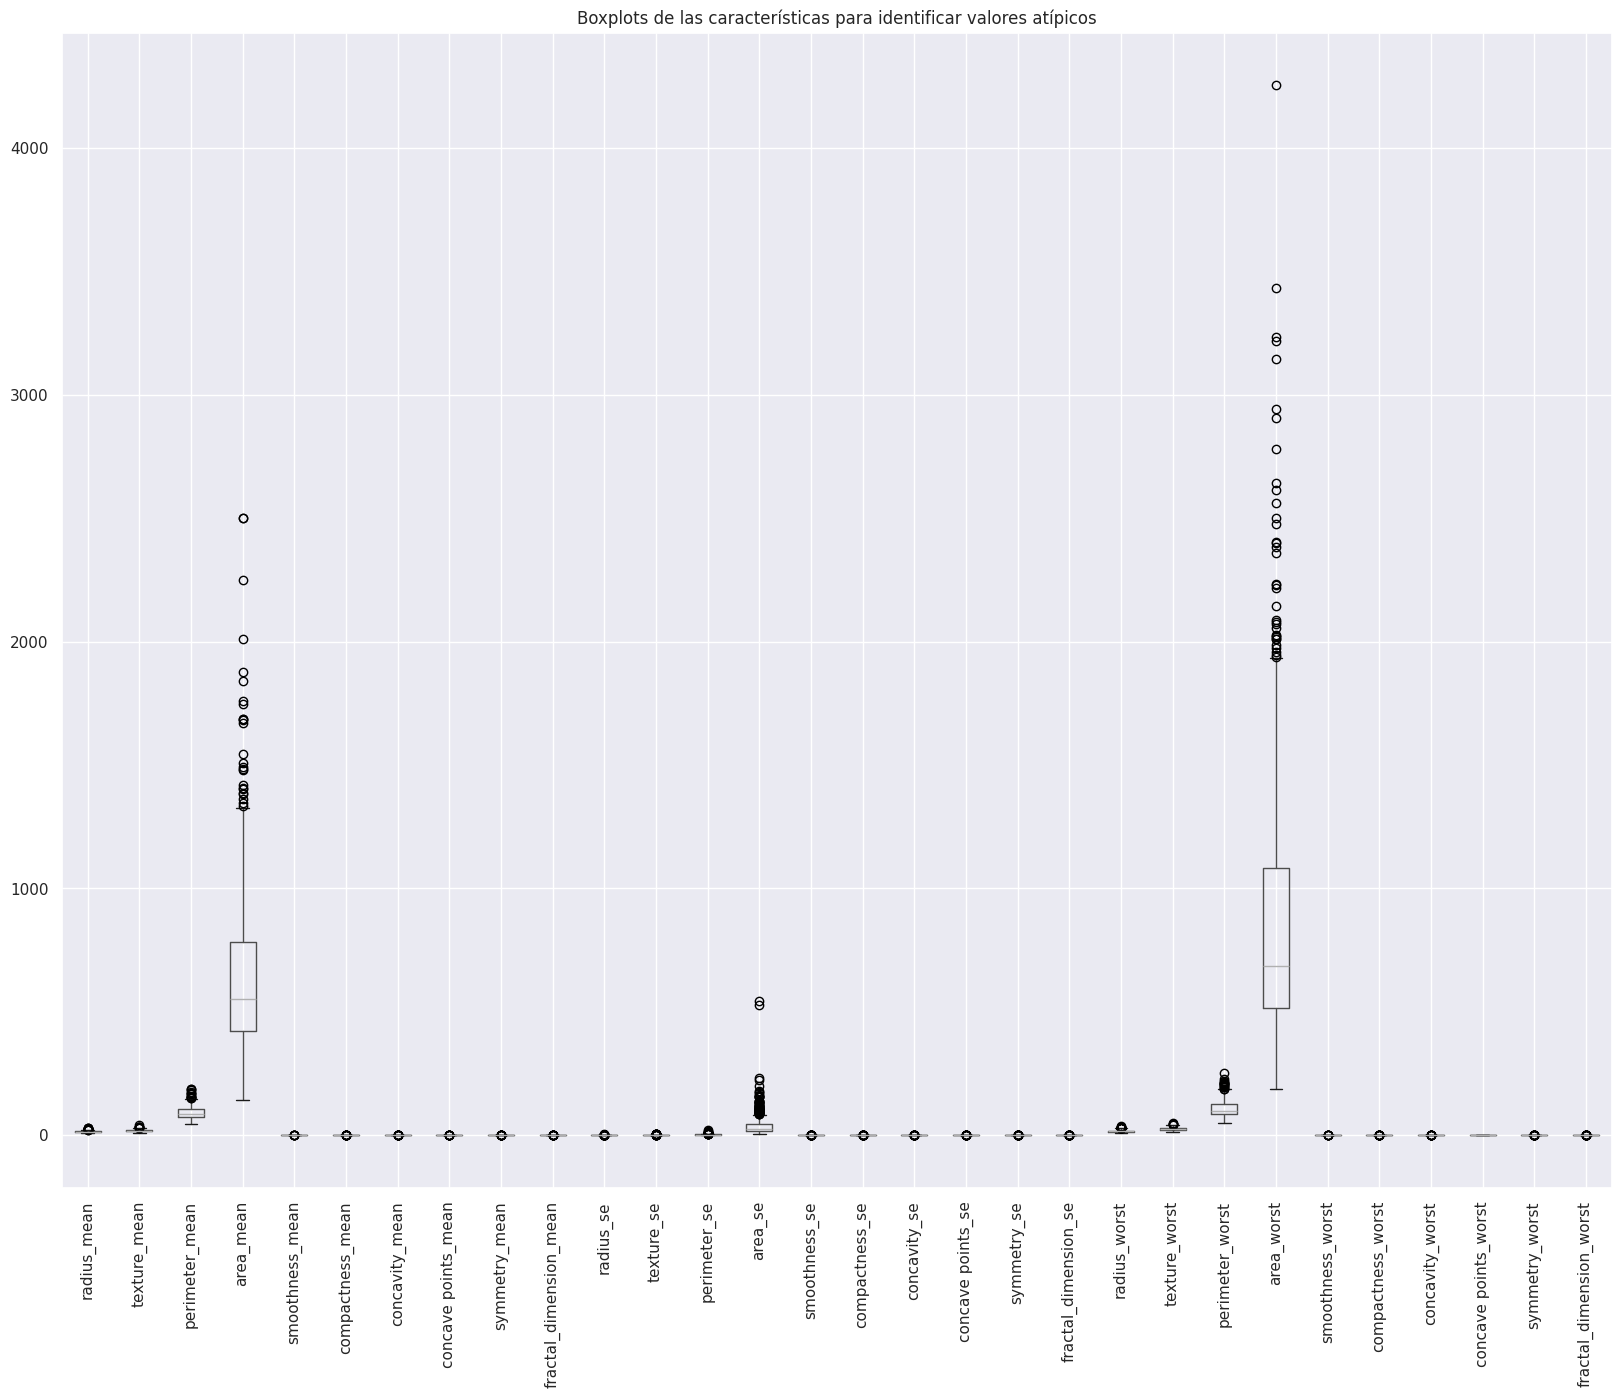


Matriz de correlación:


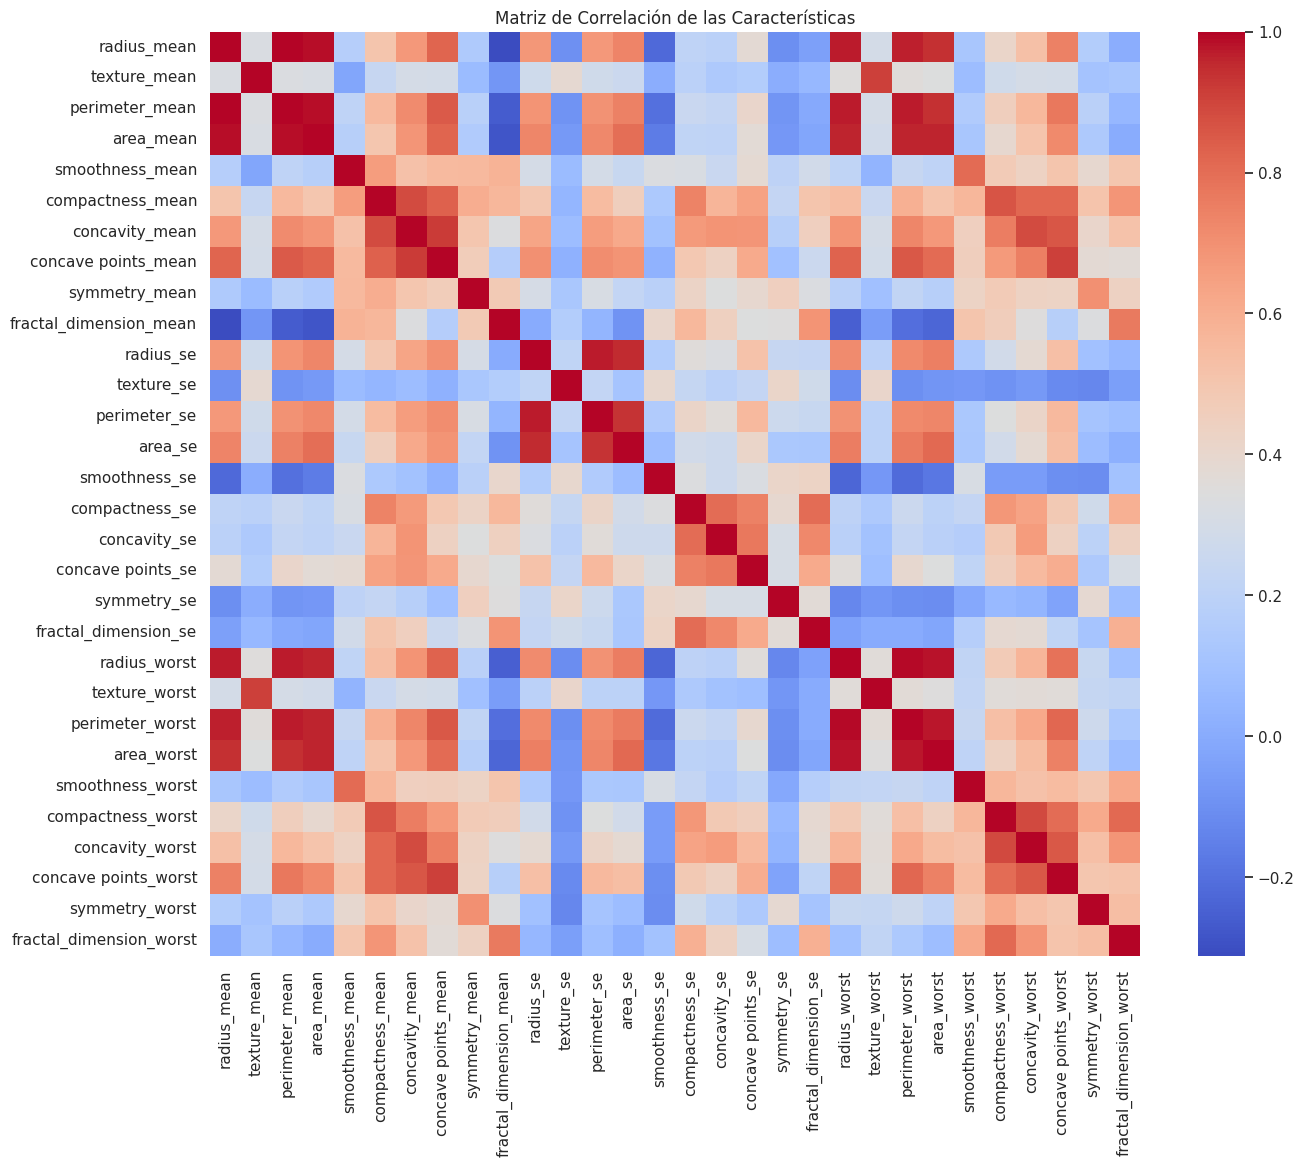

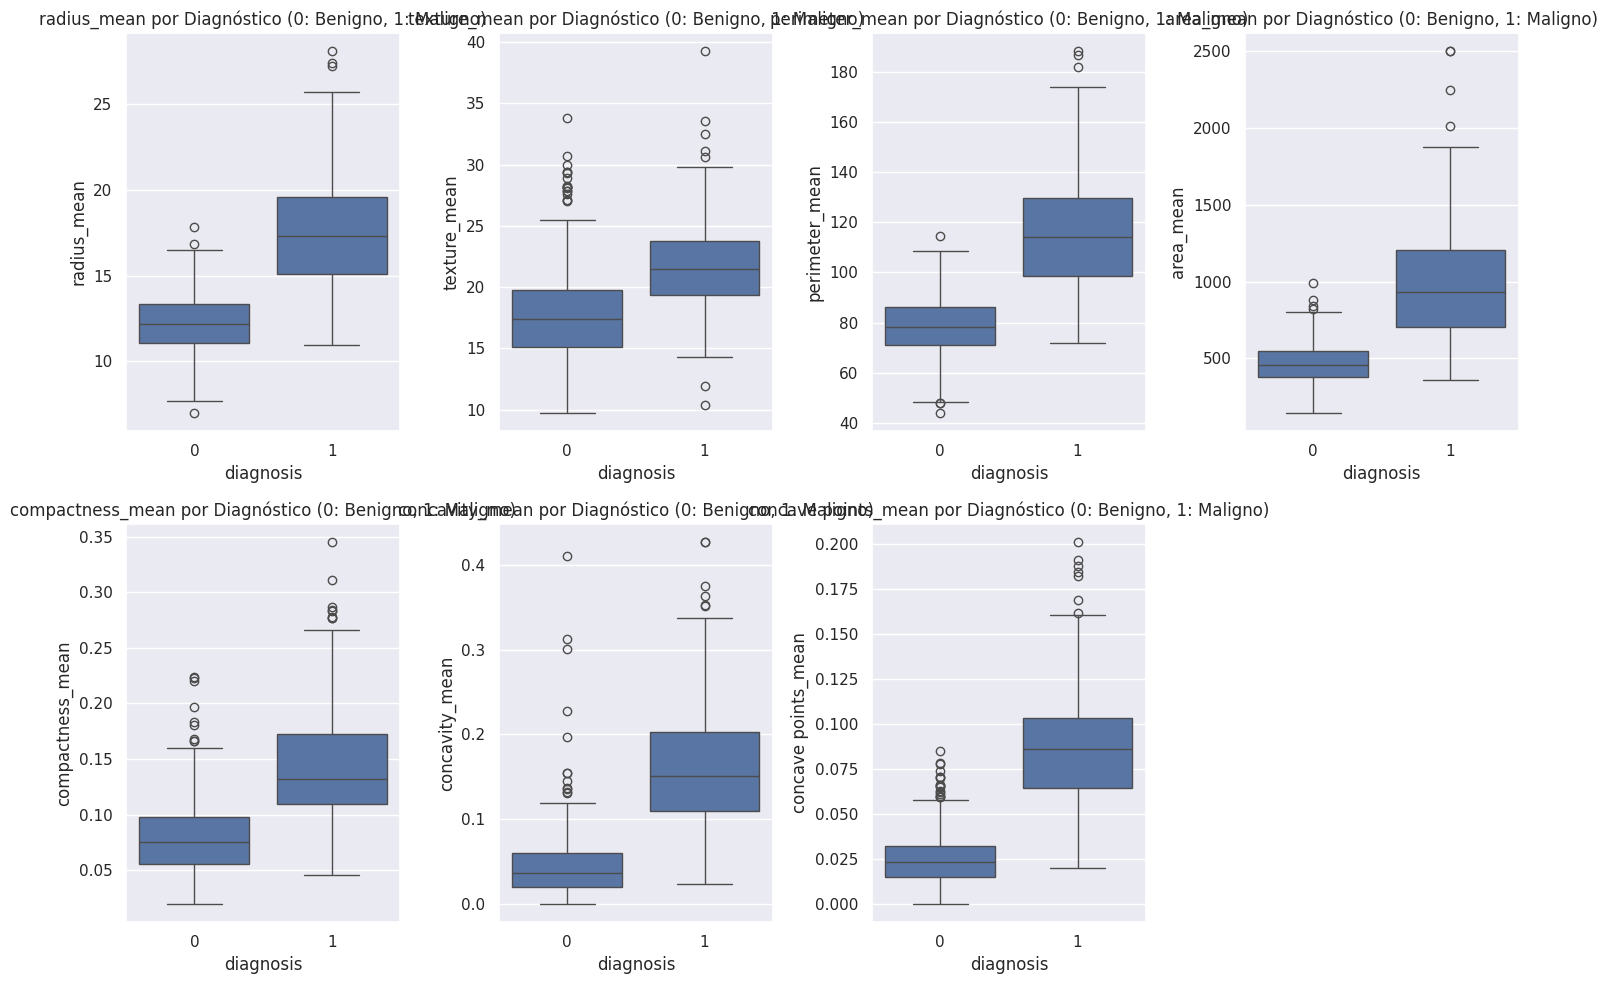

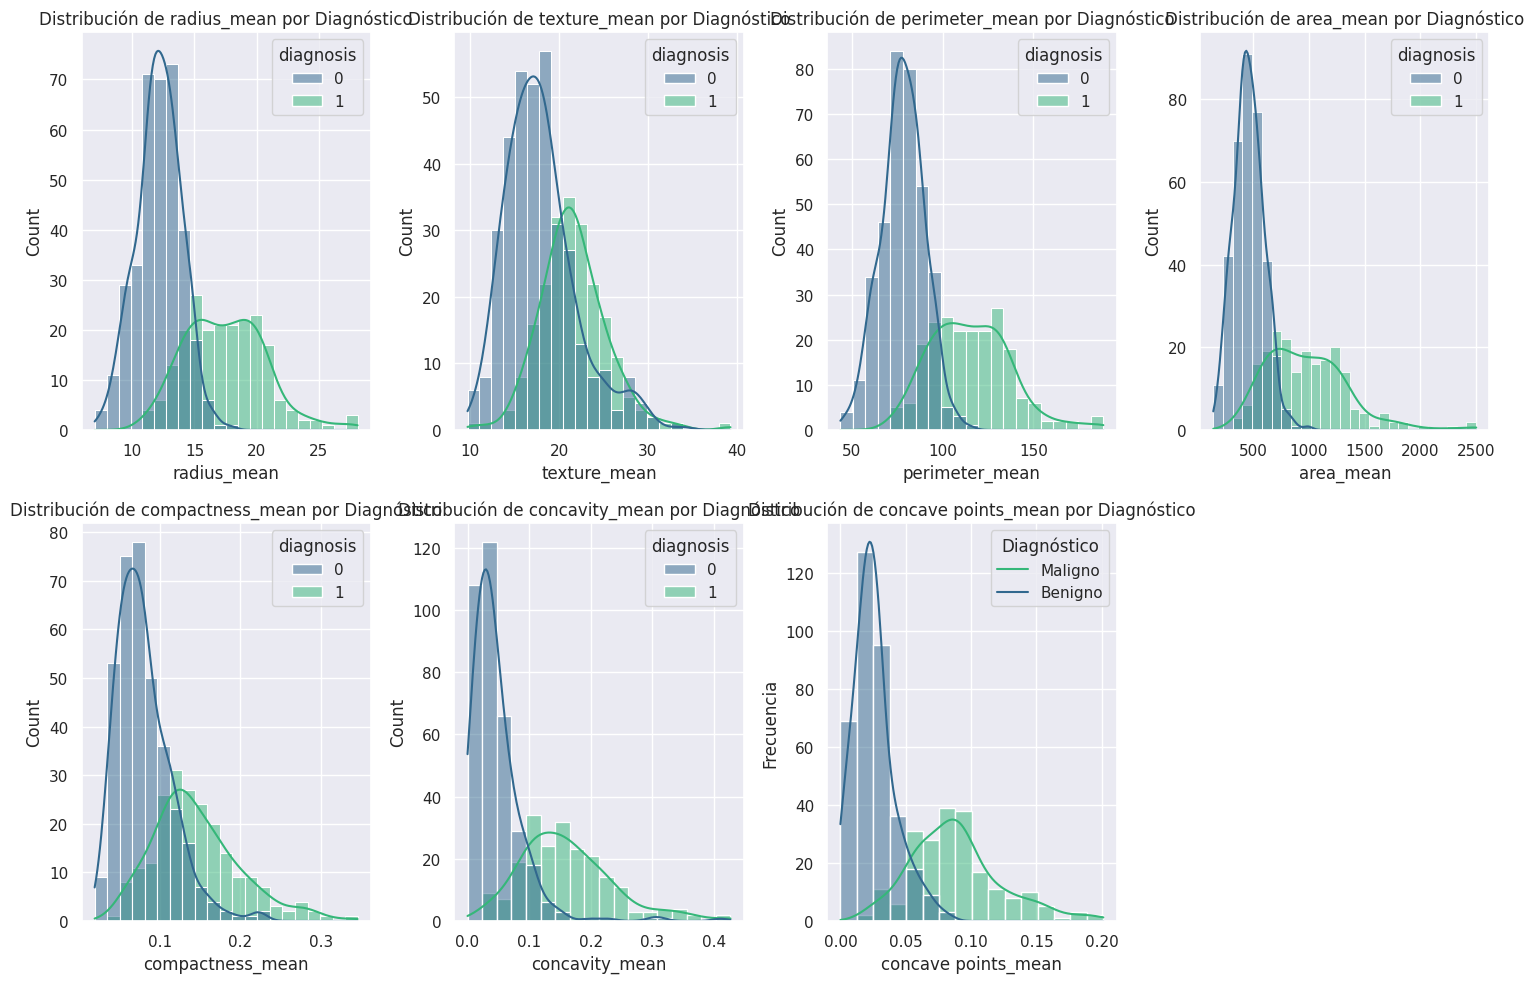

In [2]:
# 1. Análisis exploratorio profundo (EDA)

# Examine la distribución de las variables
print("Estadísticas descriptivas:")
display(df.describe())

print("\nInformación del DataFrame:")
df.info()

# Identificar valores atípicos (visualización con boxplots)
# Seleccionar solo las columnas numéricas para los boxplots
df_numeric = df.drop('diagnosis', axis=1)

# Crear boxplots para cada característica
plt.figure(figsize=(20, 15))
df_numeric.boxplot()
plt.xticks(rotation=90)
plt.title('Boxplots de las características para identificar valores atípicos')
plt.show()


# Analizar la correlación entre características
print("\nMatriz de correlación:")
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación de las Características')
plt.show()


# Visualizar las diferencias más relevantes entre tumores benignos y malignos
# Utilizar boxplots para comparar características clave por diagnóstico
features_to_compare = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                       'compactness_mean', 'concavity_mean', 'concave points_mean']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_compare):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'{feature} por Diagnóstico (0: Benigno, 1: Maligno)')
plt.tight_layout()
plt.show()


# Histograma para ver la distribución de algunas características por diagnóstico
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_compare):
    plt.subplot(2, 4, i + 1)
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, palette='viridis')
    plt.title(f'Distribución de {feature} por Diagnóstico')
plt.xlabel(feature)
plt.ylabel('Frecuencia')
plt.legend(title='Diagnóstico', labels=['Maligno', 'Benigno']) # Adjusted legend labels
plt.tight_layout()
plt.show()


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [3]:
# 2. Preprocesamiento de datos

# Separar características (X) y variable objetivo (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)


# Explorar una estrategia adicional de preprocesamiento: Eliminación de multicolinealidad
# Analizar la matriz de correlación para identificar características altamente correlacionadas
correlation_matrix = X_scaled.corr().abs()

# Seleccionar el triángulo superior de la matriz de correlación
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Encontrar características con correlación superior a 0.95 (umbral de ejemplo)
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Características a eliminar debido a alta multicolinealidad (correlación > 0.95): {to_drop}")

# Eliminar las características identificadas del DataFrame escalado
X_preprocessed = X_scaled.drop(columns=to_drop)

print("\nDataFrame después de eliminar características con alta multicolinealidad:")
display(X_preprocessed.head())

# Justificación de las elecciones:
print("""
Justificación de las elecciones de preprocesamiento:
- Normalización (StandardScaler): Escala las características para que tengan media 0 y desviación estándar 1. Esto es crucial para muchos algoritmos de Machine Learning (como SVM y Regresión Logística) que son sensibles a la escala de las características.
- Eliminación de multicolinealidad: La alta correlación entre características puede afectar negativamente algunos modelos, haciendo que los coeficientes sean inestables y difíciles de interpretar. Eliminar una de las características altamente correlacionadas puede mejorar la robustez del modelo y reducir la complejidad. Se eligió un umbral de 0.95 como ejemplo; este umbral puede ajustarse según sea necesario.
""")

Características a eliminar debido a alta multicolinealidad (correlación > 0.95): ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

DataFrame después de eliminar características con alta multicolinealidad:


,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,...,concave points_se,symmetry_se,fractal_dimension_se,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1.097064,-2.073335,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,...,0.660820,1.148757,0.907083,-1.359293,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
842517,1.829821,-0.353632,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,...,0.260162,-0.805450,-0.099444,-0.369203,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
84300903,1.579888,0.456187,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,...,1.424827,0.237036,0.293559,-0.023974,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
84348301,-0.768909,0.253732,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,...,1.115007,4.732680,2.047511,0.133984,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
84358402,1.750297,-1.151816,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,...,1.144205,-0.361092,0.499328,-1.466770,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



Justificación de las elecciones de preprocesamiento:
- Normalización (StandardScaler): Escala las características para que tengan media 0 y desviación estándar 1. Esto es crucial para muchos algoritmos de Machine Learning (como SVM y Regresión Logística) que son sensibles a la escala de las características.
- Eliminación de multicolinealidad: La alta correlación entre características puede afectar negativamente algunos modelos, haciendo que los coeficientes sean inestables y difíciles de interpretar. Eliminar una de las características altamente correlacionadas puede mejorar la robustez del modelo y reducir la complejidad. Se eligió un umbral de 0.95 como ejemplo; este umbral puede ajustarse según sea necesario.




3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


Varianza explicada por los 2 componentes principales: [0.43086476 0.1424245 ]
Varianza total explicada por los 2 componentes principales: 0.5732892594839389


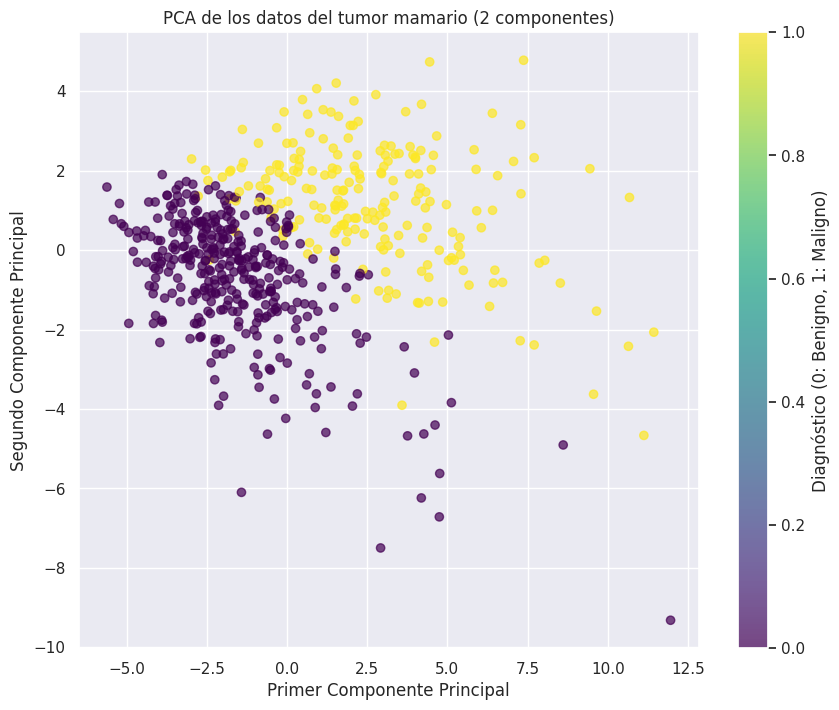


Justificación de la reducción de dimensionalidad (PCA):
- PCA es un método común para reducir la dimensionalidad manteniendo la mayor cantidad de varianza posible.
- Se eligieron 2 componentes principales para permitir una visualización sencilla en un gráfico 2D y observar si las clases (benigno/maligno) se separan visualmente.
- La varianza explicada indica cuánta información (variabilidad) de los datos originales es retenida por los componentes principales.



In [4]:
# 3. Reducción de dimensionalidad

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización
X_pca = pca.fit_transform(X_preprocessed)

# Analizar la proporción de varianza explicada por los componentes principales
print(f"Varianza explicada por los 2 componentes principales: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada por los 2 componentes principales: {np.sum(pca.explained_variance_ratio_)}")


# Visualizar los datos en el espacio reducido por PCA
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.title('PCA de los datos del tumor mamario (2 componentes)')
plt.colorbar(label='Diagnóstico (0: Benigno, 1: Maligno)')
plt.show()

# Justificación:
print("""
Justificación de la reducción de dimensionalidad (PCA):
- PCA es un método común para reducir la dimensionalidad manteniendo la mayor cantidad de varianza posible.
- Se eligieron 2 componentes principales para permitir una visualización sencilla en un gráfico 2D y observar si las clases (benigno/maligno) se separan visualmente.
- La varianza explicada indica cuánta información (variabilidad) de los datos originales es retenida por los componentes principales.
""")


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.


In [5]:
# 4. Modelado y evaluación

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=42, stratify=y)

# Definir modelos y sus hiperparámetros para Grid Search
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=10000),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100]
        }
    },
    'SVC': {
        'model': SVC(probability=True), # probability=True needed for AUC
        'params': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf', 'linear']
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20]
        }
    }
}

results = {}

# Entrenar, optimizar e evaluar cada modelo
for name, config in models.items():
    print(f"Entrenando y optimizando {name}...")
    grid_search = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Calcular métricas de rendimiento
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Para AUC-ROC, necesitamos las probabilidades predichas para la clase positiva (1)
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
        from sklearn.metrics import roc_auc_score
        auc_roc = roc_auc_score(y_test, y_prob)
    else:
        auc_roc = "N/A" # Some models (like LinearSVC) don't have predict_proba by default

    results[name] = {
        'best_params': grid_search.best_params_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc_roc
    }

    print(f"Evaluación de {name}:")
    print(f"  Mejores parámetros: {results[name]['best_params']}")
    print(f"  Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall: {results[name]['recall']:.4f}")
    print(f"  F1-score: {results[name]['f1_score']:.4f}")
    print(f"  AUC-ROC: {results[name]['auc_roc']:.4f}" if isinstance(results[name]['auc_roc'], float) else f"  AUC-ROC: {results[name]['auc_roc']}")
    print("-" * 30)

# Comparar resultados
print("\nResumen de resultados de los modelos:")
results_df = pd.DataFrame(results).T
display(results_df)
print("Notamos que el mejor modelo es el SVC")

Entrenando y optimizando LogisticRegression...
Evaluación de LogisticRegression:
  Mejores parámetros: {'C': 10}
  Accuracy: 0.9649
  Precision: 0.9833
  Recall: 0.9219
  F1-score: 0.9516
  AUC-ROC: 0.9876
------------------------------
Entrenando y optimizando SVC...
Evaluación de SVC:
  Mejores parámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.9825
  Precision: 1.0000
  Recall: 0.9531
  F1-score: 0.9760
  AUC-ROC: 0.9978
------------------------------
Entrenando y optimizando RandomForestClassifier...
Evaluación de RandomForestClassifier:
  Mejores parámetros: {'max_depth': None, 'n_estimators': 100}
  Accuracy: 0.9532
  Precision: 0.9828
  Recall: 0.8906
  F1-score: 0.9344
  AUC-ROC: 0.9945
------------------------------

Resumen de resultados de los modelos:


,best_params,accuracy,precision,recall,f1_score,auc_roc
LogisticRegression,{'C': 10},0.964912,0.983333,0.921875,0.951613,0.987588
SVC,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.982456,1.0,0.953125,0.976,0.99781
RandomForestClassifier,"{'max_depth': None, 'n_estimators': 100}",0.953216,0.982759,0.890625,0.934426,0.994524



5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



## 5. Conclusiones y reflexiones

**Análisis de Modelos:**

Basándonos en las métricas de rendimiento obtenidas en la sección 4, podemos comparar los modelos:

*   **SVC (Support Vector Classifier)** con kernel lineal y C=0.1 obtuvo el mejor rendimiento general, con la mayor precisión (1.000), un alto recall (0.9531), un excelente F1-score (0.9760) y el AUC-ROC más alto (0.9978). Una precisión de 1.000 en el conjunto de prueba indica que este modelo no produjo falsos positivos para tumores malignos, lo cual es crucial en un contexto médico.
*   **Logistic Regression** con C=10 también mostró un rendimiento sólido, con alta precisión (0.9833) y un buen AUC-ROC (0.9876).
*   **Random Forest** con los parámetros por defecto (n_estimators=100, max_depth=None) tuvo un rendimiento ligeramente inferior en términos de accuracy y recall en comparación con SVC y Logistic Regression, aunque su precisión (0.9828) y AUC-ROC (0.9945) siguen siendo muy buenos.

**Modelo más apropiado:**

Considerando la importancia de minimizar los falsos positivos en el diagnóstico de cáncer de mama (donde un falso positivo puede generar ansiedad y procedimientos innecesarios, pero un falso negativo es mucho más grave), el **SVC** se presenta como el modelo más apropiado en este caso debido a su **precisión perfecta (1.000)** en el conjunto de prueba y su excelente capacidad general para distinguir entre clases, evidenciada por el alto AUC-ROC. Aunque el recall es ligeramente inferior al de otros modelos, la alta precisión minimiza el riesgo de diagnosticar erróneamente a un paciente benigno como maligno.

**Impacto del preprocesamiento y reducción de dimensionalidad:**

*   **Normalización:** La normalización de las características fue un paso fundamental, especialmente para modelos sensibles a la escala como SVC y Regresión Logística. Permitió que estos algoritmos convergieran más eficientemente y mejoró su capacidad para encontrar los límites de decisión óptimos.
*   **Eliminación de multicolinealidad:** Eliminar características altamente correlacionadas ayudó a reducir la redundancia en los datos y potencialmente mejoró la estabilidad de los modelos, aunque el impacto exacto en el rendimiento de estos modelos específicos puede ser menor si son robustos a la multicolinealidad. Sin embargo, en otros escenarios o con otros algoritmos, este paso puede ser crucial.
*   **Reducción de dimensionalidad (PCA):** La visualización de PCA mostró que, incluso con solo dos componentes principales, ya existe una separación notable entre los tumores benignos y malignos. Si bien solo se retuvo el 57.3% de la varianza total con 2 componentes, la clara separación visual sugiere que las características principales capturan información discriminativa relevante. En un flujo de trabajo completo, se podría experimentar con un número mayor de componentes de PCA para ver si mejora el rendimiento del modelo, aunque en este caso, los modelos con las características preprocesadas (después de la eliminación de multicolinealidad) ya lograron un rendimiento muy alto.

**Posibles mejoras o enfoques alternativos:**

*   **Explorar otros modelos:** Probar otros algoritmos de clasificación como XGBoost, LightGBM o redes neuronales podría ofrecer un rendimiento aún mejor.
*   **Técnicas de selección de características más avanzadas:** Además de la eliminación de multicolinealidad, se podrían usar métodos como la selección de características basada en la importancia del modelo (para Random Forest o modelos basados en árboles) o métodos univariados.
*   **Optimización de hiperparámetros más exhaustiva:** Realizar búsquedas de hiperparámetros más amplias o utilizar técnicas como la optimización bayesiana o la optimización de TPE (Tree-structured Parzen Estimator) podrían encontrar mejores combinaciones de parámetros.
*   **Validación cruzada anidada:** Para obtener una estimación más robusta del rendimiento del modelo generalizado, se podría implementar validación cruzada anidada, donde una capa externa se usa para evaluar el modelo y una capa interna para la optimización de hiperparámetros.
*   **Considerar el desbalance de clases:** Si el conjunto de datos estuviera desbalanceado (más tumores benignos que malignos o viceversa), se deberían aplicar técnicas para manejar el desbalance, como sobremuestreo, submuestreo o el uso de métricas de evaluación más adecuadas (como el área bajo la curva Precision-Recall). En este conjunto de datos, el desbalance no parece ser un problema significativo.
*   **Interpretación del modelo:** Para un escenario de diagnóstico médico, la interpretabilidad del modelo es crucial. Se podrían utilizar técnicas como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) para entender qué características son más importantes para las predicciones del modelo.
*   **Integración con expertise médico:** En un escenario real, el modelo de machine learning sería una herramienta de apoyo al diagnóstico, no un sustituto del juicio clínico de los profesionales de la salud. La integración con la experiencia médica es fundamental para la validación y aplicación práctica.